# Entrega 2: Preparación de Datos y Modelación

**Proyecto Final - APO III**  
**Sistema de Detección de Movimientos Humanos mediante MediaPipe**

Este notebook contiene:
1. **Preparación de datos**: Limpieza, selección de features, normalización
2. **Entrenamiento de modelos**: Random Forest, XGBoost, SVM
3. **Evaluación y comparación**: Métricas de desempeño por modelo
4. **Análisis de resultados**: Identificación de mejores prácticas

---


In [1]:
# Importaciones necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)

# XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    print("[ WARN ] XGBoost no está instalado. Instala con: pip install xgboost")
    XGBOOST_AVAILABLE = False

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("[ OK ] Librerías importadas correctamente")


[ OK ] Librerías importadas correctamente


## 1. Carga y Exploración Inicial del Dataset


In [2]:
# Cargar dataset
DATASET_PATH = "../Entrega 1/mediapipe_labels_dataset_with_derived_features.csv"

df = pd.read_csv(DATASET_PATH)
print(f"[ OK ] Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")

# Información básica
print("\nINFO Información del dataset:")
print(f"   - Total de frames: {len(df):,}")
print(f"   - Total de columnas: {len(df.columns)}")
print(f"   - Memoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


[ OK ] Dataset cargado: 10380 filas × 184 columnas

INFO Información del dataset:
   - Total de frames: 10,380
   - Total de columnas: 184
   - Memoria utilizada: 15.07 MB


INFO Distribución de etiquetas:
   Walk forward        :  2,275 frames (21.92%)
   Turn                :  1,800 frames (17.34%)
   Walk backward       :  1,578 frames (15.20%)
   Get up              :  1,468 frames (14.14%)
   Sitting             :  1,274 frames (12.27%)
   Sit down            :  1,018 frames ( 9.81%)
   Standing            :    919 frames ( 8.85%)
   Unlabeled           :     48 frames ( 0.46%)


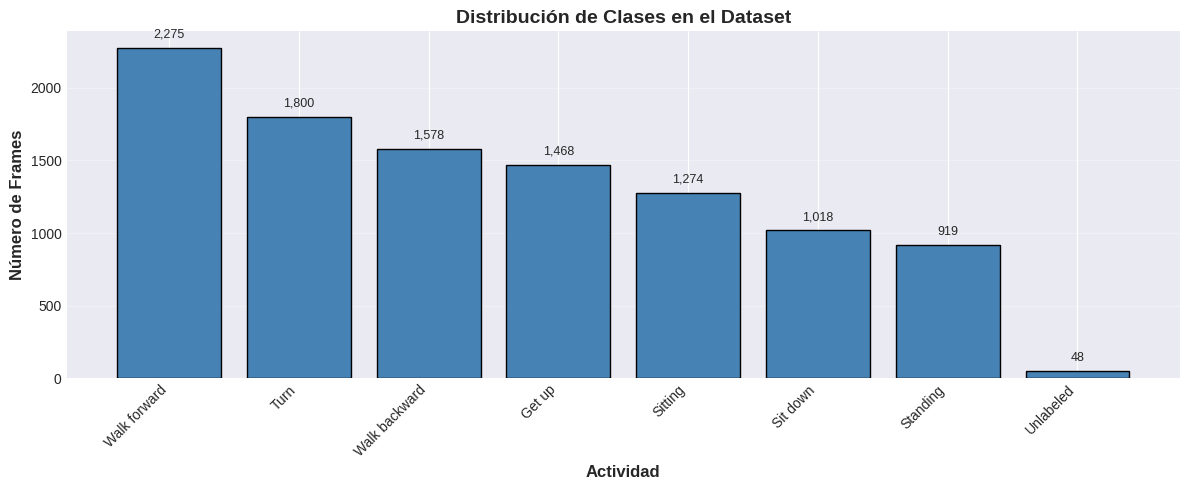


[ WARN ]  Clases con pocos datos:
   - Unlabeled: 48 frames


In [3]:
# Distribución de etiquetas
print("INFO Distribución de etiquetas:")
label_counts = df['label'].value_counts()
for label, count in label_counts.items():
    percentage = (count / len(df)) * 100
    print(f"   {label:20s}: {count:6,d} frames ({percentage:5.2f}%)")

# Visualización
plt.figure(figsize=(12, 5))
plt.bar(label_counts.index, label_counts.values, color='steelblue', edgecolor='black')
plt.xlabel('Actividad', fontsize=12, fontweight='bold')
plt.ylabel('Número de Frames', fontsize=12, fontweight='bold')
plt.title('Distribución de Clases en el Dataset', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, (label, count) in enumerate(label_counts.items()):
    plt.text(i, count + 50, f'{count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n[ WARN ]  Clases con pocos datos:")
minority_classes = label_counts[label_counts < 100]
if len(minority_classes) > 0:
    for label, count in minority_classes.items():
        print(f"   - {label}: {count} frames")
else:
    print("   Ninguna (todas tienen > 100 frames)")


## 2. Limpieza y Filtrado de Datos


In [4]:
# === 2.1. Limpieza Inicial ===
print("🧹 Limpieza de datos:")
print(f"   Frames antes de limpieza: {len(df):,}")

# Remover Unlabeled (muy pocos casos - no aporta valor predictivo)
df_clean = df[df['label'] != 'Unlabeled'].copy()
removed = len(df) - len(df_clean)
print(f"   [ OK ] Removidos {removed} frames 'Unlabeled'")
print(f"   Frames restantes: {len(df_clean):,}")

# === 2.1.1. Filtrar frames de baja calidad ===
if 'low_quality' in df_clean.columns:
    initial_count = len(df_clean)
    df_clean = df_clean[df_clean['low_quality'] == False].copy()
    removed_low_q = initial_count - len(df_clean)
    if removed_low_q > 0:
        print(f"   [ OK ] Removidos {removed_low_q} frames marcados como 'low_quality'")
        print(f"   Frames restantes: {len(df_clean):,}")

# === 2.1.2. Filtrar frames con muy baja visibilidad de landmarks ===
if 'mean_visibility' in df_clean.columns:
    initial_count = len(df_clean)
    # Filtro: mantener solo frames con visibilidad promedio > 0.5
    visibility_threshold = 0.5
    df_clean = df_clean[df_clean['mean_visibility'] > visibility_threshold].copy()
    removed_vis = initial_count - len(df_clean)
    if removed_vis > 0:
        print(f"   [ OK ] Removidos {removed_vis} frames con visibilidad promedio <= {visibility_threshold}")
        print(f"   Frames restantes: {len(df_clean):,}")

# === 2.1.3. Filtrar frames con muy pocos landmarks visibles ===
if 'num_visible_lms' in df_clean.columns:
    initial_count = len(df_clean)
    # Filtro: mantener solo frames con al menos 20 landmarks visibles (de 33)
    min_visible_lms = 20
    df_clean = df_clean[df_clean['num_visible_lms'] >= min_visible_lms].copy()
    removed_lms = initial_count - len(df_clean)
    if removed_lms > 0:
        print(f"   [ OK ] Removidos {removed_lms} frames con menos de {min_visible_lms} landmarks visibles")
        print(f"   Frames restantes: {len(df_clean):,}")

print(f"   [ OK ] TOTAL frames finales: {len(df_clean):,}")
print(f"   [ OK ] Total removidos: {len(df) - len(df_clean):,} ({((len(df) - len(df_clean))/len(df)*100):.1f}%)")

# === 2.2. Categorización de columnas ===
# Columnas METADATOS - Remover (no son features)
METADATA_COLS = [
    'video_id', 'frame_opencv', 'frame_labelstudio',
    'fps', 'timestamp_ms', 'width', 'height', 'segment_id'
]

# Columnas CALIDAD - Usar para análisis, pero no como features
QUALITY_COLS = ['mean_visibility', 'num_visible_lms', 'low_quality']

# Columnas LANDMARKS (132 columnas: x_0 a v_32)
LANDMARK_COLS = [f'{coord}_{i}' for i in range(33) 
                  for coord in ['x', 'y', 'z', 'v']]

# Columnas FEATURES DERIVADAS - USAR (valiosas)
DERIVED_FEATURE_COLS = [
    # Normalización espacial
    'hip_center_x', 'hip_center_y', 'torso_scale',
    # Bounding box
    'bbox_xmin', 'bbox_ymin', 'bbox_xmax', 'bbox_ymax', 
    'bbox_area', 'bbox_aspect',
    # Velocidades
    'speed_15', 'speed_16', 'speed_25', 'speed_26', 'speed_27', 'speed_28',
    # Ángulos
    'knee_left_deg', 'knee_right_deg',
    'elbow_left_deg', 'elbow_right_deg',
    # Features avanzadas
    'altura_normalizada', 'relacion_torso_piernas',
    'simetria_hombros', 'simetria_caderas', 'simetria_rodillas', 
    'simetria_promedio',
    'dist_vertical_cabeza_cadera', 'apertura_piernas_norm', 
    'apertura_brazos_norm',
    'ancho_hombros', 'ancho_caderas', 'relacion_hombros_caderas',
    'velocidad_centro_cuerpo', 'aceleracion_centro_cuerpo',
    'suavidad_movimiento', 'direccion_movimiento_x', 'direccion_movimiento_y',
    'velocidad_promedio_articulaciones', 'rotacion_torso', 'rotacion_cabeza',
    'fps_eff'
]

# === 2.3. Selección de Features ===
# Estrategia: Usar solo features derivadas inicialmente (menos dimensionalidad)
print("\nINFO Selección de features:")

# Verificar que las columnas existan
available_derived = [col for col in DERIVED_FEATURE_COLS if col in df_clean.columns]
print(f"   Features derivadas disponibles: {len(available_derived)}")

# Separar X e y
feature_cols = available_derived.copy()
X = df_clean[feature_cols].copy()
y = df_clean['label'].copy()

print(f"   [ OK ] Features seleccionadas: {len(feature_cols)}")
print(f"   [ OK ] Shape X: {X.shape}")

# === 2.4. Análisis de Calidad de Datos ===
print("\nINFO Análisis de calidad de datos:")
print(f"   Valores faltantes totales: {X.isnull().sum().sum()}")

missing_cols = X.columns[X.isnull().any()].tolist()
if len(missing_cols) > 0:
    print(f"   [ WARN ]  Columnas con valores faltantes ({len(missing_cols)}):")
    for col in missing_cols[:10]:  # Mostrar solo las primeras 10
        missing_count = X[col].isnull().sum()
        missing_pct = (missing_count / len(X)) * 100
        print(f"      - {col}: {missing_count} ({missing_pct:.2f}%)")
    if len(missing_cols) > 10:
        print(f"      ... y {len(missing_cols) - 10} más")
else:
    print("   [ OK ] No hay valores faltantes")

# === 2.5. Manejo de Valores Faltantes ===
if X.isnull().any().any():
    # Estrategia: usar mediana (robusta a outliers)
    imputer = SimpleImputer(strategy='median')
    X_imputed = pd.DataFrame(
        imputer.fit_transform(X),
        columns=X.columns,
        index=X.index
    )
    X = X_imputed
    print("\n[ OK ] Valores faltantes imputados con mediana")
    print(f"   Valores faltantes después: {X.isnull().sum().sum()}")
else:
    print("\n[ OK ] No hay valores faltantes que imputar")

# === 2.6. Manejo de Outliers (Capping con IQR) ===
def cap_outliers_iqr(df, factor=3.0):
    """
    Limita outliers usando método IQR.
    factor=3.0 es menos agresivo que el estándar (1.5)
    """
    df_capped = df.copy()
    for col in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR
        df_capped[col] = df_capped[col].clip(lower_bound, upper_bound)
    return df_capped

print("\n🔧 Aplicando capping de outliers (IQR factor=3.0)...")
X = cap_outliers_iqr(X, factor=3.0)
print("[ OK ] Outliers moderados (capping IQR)")

# === 2.7. Encoding de Labels ===
print("\n🔤 Encoding de labels:")
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Guardar mapeo para interpretación posterior
label_mapping = {i: label for i, label in enumerate(le.classes_)}
print(f"   Mapeo de clases:")
for class_id, label_name in label_mapping.items():
    print(f"      {class_id} -> {label_name}")

# === 2.8. División Estratificada Train/Validation/Test ===
print("\n📦 División de datos:")

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.3,
    stratify=y_encoded,  # Mantener proporción de clases
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print(f"   [ OK ] Train: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   [ OK ] Val:   {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"   [ OK ] Test:  {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

# Verificar distribución de clases en cada split
print("\nINFO Distribución de clases en Train:")
for class_id, count in sorted(Counter(y_train).items()):
    percentage = (count / len(y_train)) * 100
    print(f"   {label_mapping[class_id]:20s}: {count:5d} ({percentage:5.1f}%)")

# === 2.8.1. Análisis y Remoción de Features con Baja Varianza (ANTES de estandarizar) ===
print("\n🔍 Análisis de varianza de features...")
variance_threshold = 0.01  # Remover features con varianza < 0.01

selector_var = VarianceThreshold(threshold=variance_threshold)
X_train_var = selector_var.fit_transform(X_train)
X_val_var = selector_var.transform(X_val)
X_test_var = selector_var.transform(X_test)

removed_features_var = X_train.shape[1] - X_train_var.shape[1]
if removed_features_var > 0:
    removed_feature_names = X_train.columns[~selector_var.get_support()].tolist()
    print(f"   [ WARN ]  Removidas {removed_features_var} features con varianza < {variance_threshold}:")
    for feat in removed_feature_names[:10]:
        print(f"      - {feat}")
    if len(removed_feature_names) > 10:
        print(f"      ... y {len(removed_feature_names) - 10} más")
    
    # Actualizar columnas
    feature_cols_after_var = X_train.columns[selector_var.get_support()].tolist()
    X_train = pd.DataFrame(X_train_var, columns=feature_cols_after_var, index=X_train.index)
    X_val = pd.DataFrame(X_val_var, columns=feature_cols_after_var, index=X_val.index)
    X_test = pd.DataFrame(X_test_var, columns=feature_cols_after_var, index=X_test.index)
    print(f"   [ OK ] Features restantes: {X_train.shape[1]}")
else:
    print(f"   [ OK ] Todas las features tienen varianza >= {variance_threshold}")

# === 2.9. Estandarización ===
print("\n📏 Estandarización de features...")
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("[ OK ] Features estandarizadas (StandardScaler)")

# === 2.9.2. Análisis de Correlación (solo informativo, no removemos aún) ===
print("\n🔍 Análisis de correlación entre features...")
corr_matrix = X_train_scaled.corr().abs()
# Encontrar pares de features altamente correlacionadas (> 0.95)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.95:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if len(high_corr_pairs) > 0:
    print(f"   [ WARN ]  Encontradas {len(high_corr_pairs)} parejas de features altamente correlacionadas (>0.95):")
    for feat1, feat2, corr_val in high_corr_pairs[:10]:
        print(f"      - {feat1} ↔ {feat2}: {corr_val:.3f}")
    if len(high_corr_pairs) > 10:
        print(f"      ... y {len(high_corr_pairs) - 10} parejas más")
    print("   💡 Considera remover una de cada par para reducir redundancia")
else:
    print(f"   [ OK ] No hay features altamente correlacionadas (>0.95)")

# === 2.10. Resumen Final ===
print("\n" + "="*60)
print("[ OK ] PREPARACIÓN DE DATOS COMPLETADA")
print("="*60)
print(f"   Features seleccionadas: {X_train_scaled.shape[1]}")
print(f"   Train samples: {len(X_train_scaled):,}")
print(f"   Validation samples: {len(X_val_scaled):,}")
print(f"   Test samples: {len(X_test_scaled):,}")
print(f"   Clases: {len(np.unique(y_train))}")
print("="*60)

# Guardar objetos para uso posterior (opcional)
import joblib
try:
    joblib.dump(scaler, 'scaler.joblib')
    joblib.dump(le, 'label_encoder.joblib')
    print("\n[ SAVE ] Objetos guardados: scaler.joblib, label_encoder.joblib")
except:
    print("\n[ WARN ]  No se pudieron guardar los objetos (directorio puede no existir)")


🧹 Limpieza de datos:
   Frames antes de limpieza: 10,380
   [ OK ] Removidos 48 frames 'Unlabeled'
   Frames restantes: 10,332
   [ OK ] TOTAL frames finales: 10,332
   [ OK ] Total removidos: 48 (0.5%)

INFO Selección de features:
   Features derivadas disponibles: 40
   [ OK ] Features seleccionadas: 40
   [ OK ] Shape X: (10332, 40)

INFO Análisis de calidad de datos:
   Valores faltantes totales: 0
   [ OK ] No hay valores faltantes

[ OK ] No hay valores faltantes que imputar

🔧 Aplicando capping de outliers (IQR factor=3.0)...
[ OK ] Outliers moderados (capping IQR)

🔤 Encoding de labels:
   Mapeo de clases:
      0 -> Get up
      1 -> Sit down
      2 -> Sitting
      3 -> Standing
      4 -> Turn
      5 -> Walk backward
      6 -> Walk forward

📦 División de datos:
   [ OK ] Train: 7,232 (70.0%)
   [ OK ] Val:   1,550 (15.0%)
   [ OK ] Test:  1,550 (15.0%)

INFO Distribución de clases en Train:
   Get up              :  1028 ( 14.2%)
   Sit down            :   713 (  9.9%)
  

## 3. Entrenamiento de Modelos

Ahora entrenaremos y compararemos tres modelos diferentes:
1. **Random Forest**: Baseline robusto y fácil de interpretar
2. **XGBoost**: Modelo avanzado con excelente rendimiento
3. **SVM**: Modelo de soporte vectorial para comparación


In [5]:
# === 3.1. Entrenamiento Random Forest ===
print("[ MODEL ] Entrenando Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',  # Maneja el desbalance de clases
    random_state=42,
    n_jobs=-1,  # Usa todos los cores disponibles
    verbose=0
)

import time
start_time = time.time()
rf_model.fit(X_train_scaled, y_train)
training_time_rf = time.time() - start_time

print(f"[ OK ] Random Forest entrenado en {training_time_rf:.2f} segundos")

# Predicciones
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_val_pred_rf = rf_model.predict(X_val_scaled)

# Métricas
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
val_acc_rf = accuracy_score(y_val, y_val_pred_rf)
train_f1_rf = f1_score(y_train, y_train_pred_rf, average='macro')
val_f1_rf = f1_score(y_val, y_val_pred_rf, average='macro')

print(f"\nINFO Métricas Random Forest:")
print(f"   Train Accuracy: {train_acc_rf:.4f}")
print(f"   Val Accuracy:   {val_acc_rf:.4f}")
print(f"   Train F1-Score: {train_f1_rf:.4f}")
print(f"   Val F1-Score:   {val_f1_rf:.4f}")


[ MODEL ] Entrenando Random Forest...
[ OK ] Random Forest entrenado en 0.70 segundos

INFO Métricas Random Forest:
   Train Accuracy: 0.9985
   Val Accuracy:   0.9361
   Train F1-Score: 0.9984
   Val F1-Score:   0.9353


In [6]:
# === 3.2. Entrenamiento XGBoost ===
if XGBOOST_AVAILABLE:
    print("\n[ MODEL ] Entrenando XGBoost...")
    
    # Calcular pesos de clases para XGBoost
    class_counts = Counter(y_train)
    total = len(y_train)
    class_weights = {class_id: total / (len(class_counts) * count) 
                     for class_id, count in class_counts.items()}
    
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss',
        use_label_encoder=False
    )
    
    # Entrenar con pesos de clases
    start_time = time.time()
    sample_weights = np.array([class_weights[y] for y in y_train])
    xgb_model.fit(X_train_scaled, y_train, sample_weight=sample_weights)
    training_time_xgb = time.time() - start_time
    
    print(f"[ OK ] XGBoost entrenado en {training_time_xgb:.2f} segundos")
    
    # Predicciones
    y_train_pred_xgb = xgb_model.predict(X_train_scaled)
    y_val_pred_xgb = xgb_model.predict(X_val_scaled)
    
    # Métricas
    train_acc_xgb = accuracy_score(y_train, y_train_pred_xgb)
    val_acc_xgb = accuracy_score(y_val, y_val_pred_xgb)
    train_f1_xgb = f1_score(y_train, y_train_pred_xgb, average='macro')
    val_f1_xgb = f1_score(y_val, y_val_pred_xgb, average='macro')
    
    print(f"\nINFO Métricas XGBoost:")
    print(f"   Train Accuracy: {train_acc_xgb:.4f}")
    print(f"   Val Accuracy:   {val_acc_xgb:.4f}")
    print(f"   Train F1-Score: {train_f1_xgb:.4f}")
    print(f"   Val F1-Score:   {val_f1_xgb:.4f}")
else:
    print("\n[ WARN ] XGBoost no disponible - saltando este modelo")
    xgb_model = None



[ MODEL ] Entrenando XGBoost...
[ OK ] XGBoost entrenado en 3.90 segundos

INFO Métricas XGBoost:
   Train Accuracy: 0.9941
   Val Accuracy:   0.9303
   Train F1-Score: 0.9944
   Val F1-Score:   0.9291


In [7]:
# === 3.3. Entrenamiento SVM ===
print("\n[ MODEL ] Entrenando SVM (esto puede tardar varios minutos)...")

svm_model = SVC(
    kernel='rbf',
    C=10.0,
    gamma='scale',
    class_weight='balanced',  # Maneja el desbalance
    probability=True,  # Permite predict_proba()
    random_state=42,
    verbose=True
)

start_time = time.time()
svm_model.fit(X_train_scaled, y_train)
training_time_svm = time.time() - start_time

print(f"[ OK ] SVM entrenado en {training_time_svm:.2f} segundos")

# Predicciones
y_train_pred_svm = svm_model.predict(X_train_scaled)
y_val_pred_svm = svm_model.predict(X_val_scaled)

# Métricas
train_acc_svm = accuracy_score(y_train, y_train_pred_svm)
val_acc_svm = accuracy_score(y_val, y_val_pred_svm)
train_f1_svm = f1_score(y_train, y_train_pred_svm, average='macro')
val_f1_svm = f1_score(y_val, y_val_pred_svm, average='macro')

print(f"\nINFO Métricas SVM:")
print(f"   Train Accuracy: {train_acc_svm:.4f}")
print(f"   Val Accuracy:   {val_acc_svm:.4f}")
print(f"   Train F1-Score: {train_f1_svm:.4f}")
print(f"   Val F1-Score:   {val_f1_svm:.4f}")



[ MODEL ] Entrenando SVM (esto puede tardar varios minutos)...
[LibSVM].*.*
optimization finished, #iter = 2626
obj = -1238.748607, rho = 0.015197
nSV = 332, nBSV = 86
Total nSV = 332
..*.*
optimization finished, #iter = 3022
obj = -1226.253610, rho = 0.216722
nSV = 340, nBSV = 93
Total nSV = 340
.*.*
optimization finished, #iter = 2689
obj = -1119.388176, rho = 0.157504
nSV = 324, nBSV = 74
Total nSV = 324
.*.*
optimization finished, #iter = 2997
obj = -1185.232205, rho = 0.086705
nSV = 333, nBSV = 82
Total nSV = 333
.*.*
optimization finished, #iter = 2643
obj = -1188.307350, rho = 0.217708
nSV = 323, nBSV = 81
Total nSV = 323
.*..*
optimization finished, #iter = 3163
obj = -1374.527208, rho = -0.172133
nSV = 366, nBSV = 113
.*.*
optimization finished, #iter = 2557
obj = -2223.110928, rho = -0.550789
nSV = 430, nBSV = 203
Total nSV = 430
.*.*
optimization finished, #iter = 2706
obj = -2287.882491, rho = -0.341103
nSV = 433, nBSV = 206
Total nSV = 433
.*.*
optimization finished, #ite

## 4. Comparación de Modelos


In [8]:
# === 4.1. Resumen Comparativo ===
print("="*70)
print("INFO COMPARACIÓN DE MODELOS - VALIDATION SET")
print("="*70)

# Construir resultados según disponibilidad
model_names = ['Random Forest', 'SVM']
train_accs = [train_acc_rf, train_acc_svm]
val_accs = [val_acc_rf, val_acc_svm]
train_f1s = [train_f1_rf, train_f1_svm]
val_f1s = [val_f1_rf, val_f1_svm]
times = [training_time_rf, training_time_svm]

if XGBOOST_AVAILABLE:
    model_names.insert(1, 'XGBoost')
    train_accs.insert(1, train_acc_xgb)
    val_accs.insert(1, val_acc_xgb)
    train_f1s.insert(1, train_f1_xgb)
    val_f1s.insert(1, val_f1_xgb)
    times.insert(1, training_time_xgb)

results = {
    'Modelo': model_names,
    'Train Accuracy': train_accs,
    'Val Accuracy': val_accs,
    'Train F1 (macro)': train_f1s,
    'Val F1 (macro)': val_f1s,
    'Tiempo (s)': times
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Val F1 (macro)', ascending=False)
print(results_df.to_string(index=False))

print("\n" + "="*70)
print("[ BEST ] MEJOR MODELO (según F1-Score en Validation):")
best_model_idx = results_df['Val F1 (macro)'].idxmax()
best_model_name = results_df.iloc[best_model_idx]['Modelo']
print(f"   {best_model_name} - F1-Score: {results_df.iloc[best_model_idx]['Val F1 (macro)']:.4f}")
print("="*70)


INFO COMPARACIÓN DE MODELOS - VALIDATION SET
       Modelo  Train Accuracy  Val Accuracy  Train F1 (macro)  Val F1 (macro)  Tiempo (s)
Random Forest        0.998479      0.936129          0.998442        0.935350    0.696193
      XGBoost        0.994054      0.930323          0.994396        0.929080    3.901757
          SVM        0.949115      0.894839          0.946166        0.889767    4.409400

[ BEST ] MEJOR MODELO (según F1-Score en Validation):
   Random Forest - F1-Score: 0.9353


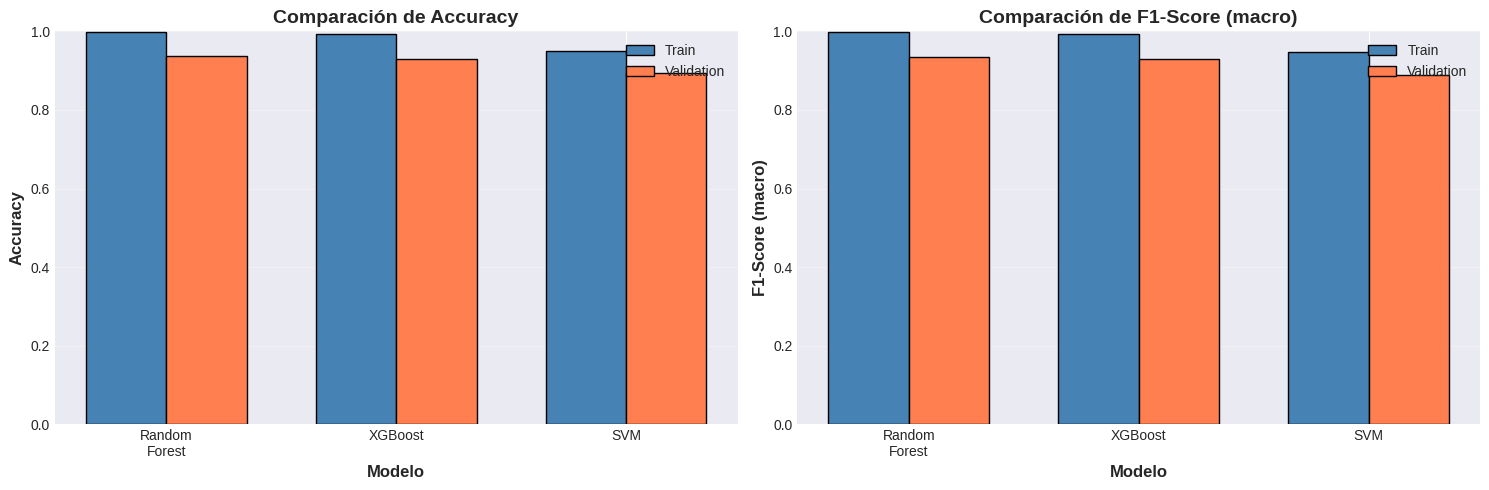

In [9]:
# === 4.2. Visualización Comparativa ===
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Preparar datos según disponibilidad
models_viz = ['Random\nForest', 'SVM']
train_accs_viz = [train_acc_rf, train_acc_svm]
val_accs_viz = [val_acc_rf, val_acc_svm]
train_f1s_viz = [train_f1_rf, train_f1_svm]
val_f1s_viz = [val_f1_rf, val_f1_svm]

if XGBOOST_AVAILABLE:
    models_viz.insert(1, 'XGBoost')
    train_accs_viz.insert(1, train_acc_xgb)
    val_accs_viz.insert(1, val_acc_xgb)
    train_f1s_viz.insert(1, train_f1_xgb)
    val_f1s_viz.insert(1, val_f1_xgb)

x = np.arange(len(models_viz))
width = 0.35

# Gráfico de Accuracy
axes[0].bar(x - width/2, train_accs_viz, width, label='Train', color='steelblue', edgecolor='black')
axes[0].bar(x + width/2, val_accs_viz, width, label='Validation', color='coral', edgecolor='black')
axes[0].set_xlabel('Modelo', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Comparación de Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_viz)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

# Gráfico de F1-Score
axes[1].bar(x - width/2, train_f1s_viz, width, label='Train', color='steelblue', edgecolor='black')
axes[1].bar(x + width/2, val_f1s_viz, width, label='Validation', color='coral', edgecolor='black')
axes[1].set_xlabel('Modelo', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1-Score (macro)', fontsize=12, fontweight='bold')
axes[1].set_title('Comparación de F1-Score (macro)', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_viz)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()


## 5. Evaluación en Test Set y Análisis Detallado

Evaluamos el mejor modelo en el conjunto de test (datos nunca vistos)


In [10]:
# === 5.1. Seleccionar el mejor modelo y evaluar en Test ===
print("[ TEST ] Evaluación en Test Set (datos nunca vistos)\n")

# Seleccionar mejor modelo basado en F1-Score en validation
if XGBOOST_AVAILABLE:
    if val_f1_xgb >= max(val_f1_rf, val_f1_svm):
        best_model = xgb_model
        best_model_name = "XGBoost"
        y_test_pred = xgb_model.predict(X_test_scaled)
    elif val_f1_rf >= val_f1_svm:
        best_model = rf_model
        best_model_name = "Random Forest"
        y_test_pred = rf_model.predict(X_test_scaled)
    else:
        best_model = svm_model
        best_model_name = "SVM"
        y_test_pred = svm_model.predict(X_test_scaled)
else:
    if val_f1_rf >= val_f1_svm:
        best_model = rf_model
        best_model_name = "Random Forest"
        y_test_pred = rf_model.predict(X_test_scaled)
    else:
        best_model = svm_model
        best_model_name = "SVM"
        y_test_pred = svm_model.predict(X_test_scaled)

print(f"[ OK ] Modelo seleccionado: {best_model_name}\n")

# Métricas en Test
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1_macro = f1_score(y_test, y_test_pred, average='macro')
test_f1_weighted = f1_score(y_test, y_test_pred, average='weighted')
test_precision = precision_score(y_test, y_test_pred, average='macro')
test_recall = recall_score(y_test, y_test_pred, average='macro')

print("="*70)
print("INFO MÉTRICAS EN TEST SET:")
print("="*70)
print(f"   Accuracy:        {test_accuracy:.4f}")
print(f"   Precision:      {test_precision:.4f}")
print(f"   Recall:         {test_recall:.4f}")
print(f"   F1-Score (macro):    {test_f1_macro:.4f}")
print(f"   F1-Score (weighted): {test_f1_weighted:.4f}")
print("="*70)


[ TEST ] Evaluación en Test Set (datos nunca vistos)

[ OK ] Modelo seleccionado: Random Forest

INFO MÉTRICAS EN TEST SET:
   Accuracy:        0.9277
   Precision:      0.9338
   Recall:         0.9268
   F1-Score (macro):    0.9295
   F1-Score (weighted): 0.9275


In [11]:
# === 5.2. Reporte de Clasificación por Clase ===
print("\n[ REPORT ] REPORTE DE CLASIFICACIÓN POR CLASE:\n")
print(classification_report(y_test, y_test_pred, 
                          target_names=[label_mapping[i] for i in sorted(label_mapping.keys())],
                          digits=4))



[ REPORT ] REPORTE DE CLASIFICACIÓN POR CLASE:

               precision    recall  f1-score   support

       Get up     0.9398    0.9227    0.9312       220
     Sit down     0.9793    0.9281    0.9530       153
      Sitting     0.9394    0.9738    0.9563       191
     Standing     0.9265    0.9130    0.9197       138
         Turn     0.9508    0.8593    0.9027       270
Walk backward     0.9083    0.9198    0.9140       237
 Walk forward     0.8922    0.9707    0.9298       341

     accuracy                         0.9277      1550
    macro avg     0.9338    0.9268    0.9295      1550
 weighted avg     0.9291    0.9277    0.9275      1550



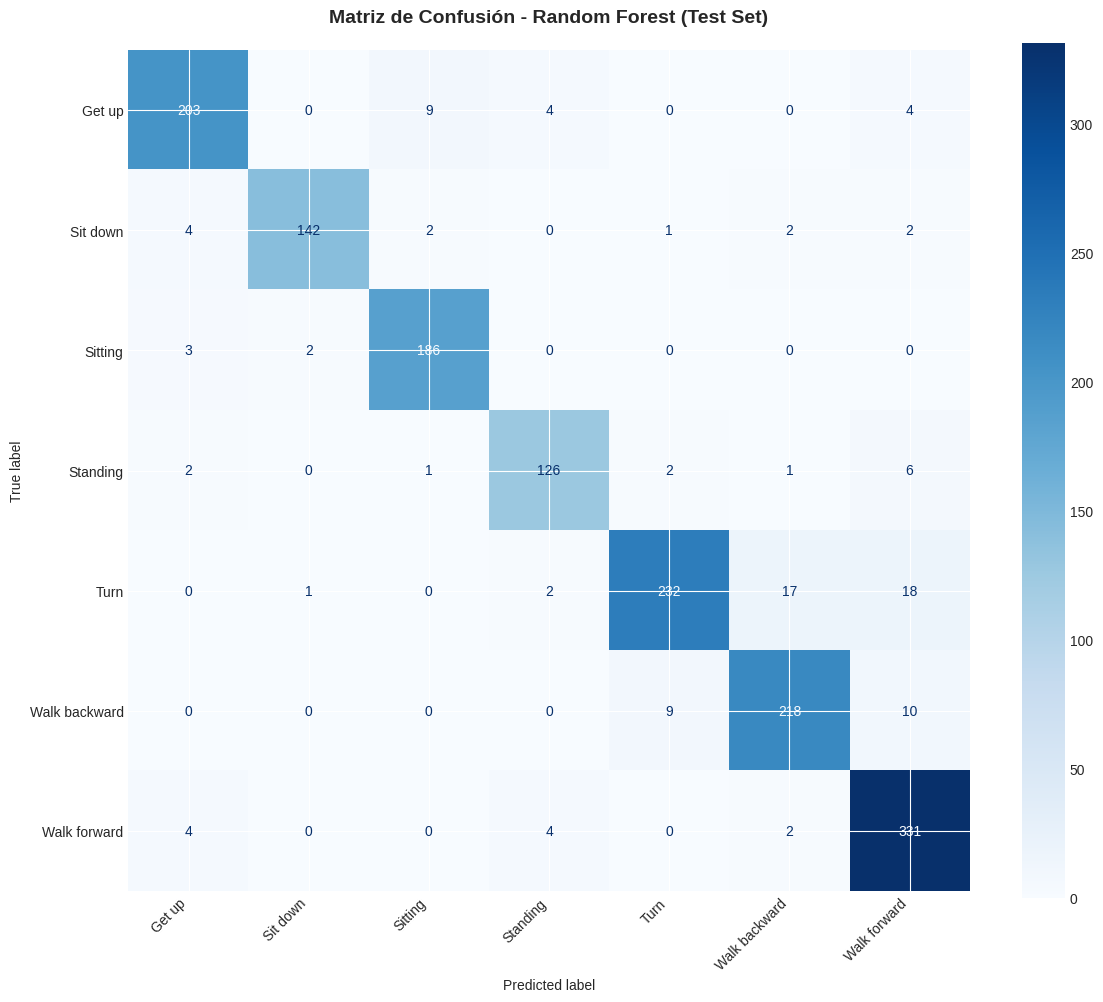


🔍 Análisis de Errores Más Comunes:
--------------------------------------------------
   Turn                 → Predicho como Walk forward        :  18 veces
   Turn                 → Predicho como Walk backward       :  17 veces
   Walk backward        → Predicho como Walk forward        :  10 veces
   Get up               → Predicho como Sitting             :   9 veces
   Walk backward        → Predicho como Turn                :   9 veces


In [12]:
# === 5.3. Matriz de Confusión ===
cm = confusion_matrix(y_test, y_test_pred)
class_names = [label_mapping[i] for i in sorted(label_mapping.keys())]

plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=plt.gca(), values_format='d')
plt.title(f'Matriz de Confusión - {best_model_name} (Test Set)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Análisis de errores más comunes
print("\n🔍 Análisis de Errores Más Comunes:")
print("-" * 50)
error_counts = {}
for i in range(len(y_test)):
    if y_test[i] != y_test_pred[i]:
        error = (label_mapping[y_test[i]], label_mapping[y_test_pred[i]])
        error_counts[error] = error_counts.get(error, 0) + 1

# Mostrar top 5 errores más frecuentes
top_errors = sorted(error_counts.items(), key=lambda x: x[1], reverse=True)[:5]
for (true_label, pred_label), count in top_errors:
    print(f"   {true_label:20s} → Predicho como {pred_label:20s}: {count:3d} veces")



INFO Análisis de Importancia de Features:

[ MODEL ] Random Forest - Top 15 Features:
------------------------------------------------------------
                 feature  importance
      altura_normalizada    0.092150
  relacion_torso_piernas    0.088657
               bbox_xmax    0.087253
   apertura_piernas_norm    0.067928
             bbox_aspect    0.062793
relacion_hombros_caderas    0.058478
           knee_left_deg    0.051301
     suavidad_movimiento    0.049698
    apertura_brazos_norm    0.046429
         elbow_right_deg    0.045907
          elbow_left_deg    0.042933
          knee_right_deg    0.042835
                speed_28    0.042342
                speed_27    0.039314
                 fps_eff    0.037083

[ MODEL ] XGBoost - Top 15 Features:
------------------------------------------------------------
                 feature  importance
  relacion_torso_piernas    0.117079
                speed_28    0.084732
                speed_16    0.061447
   apertura_p

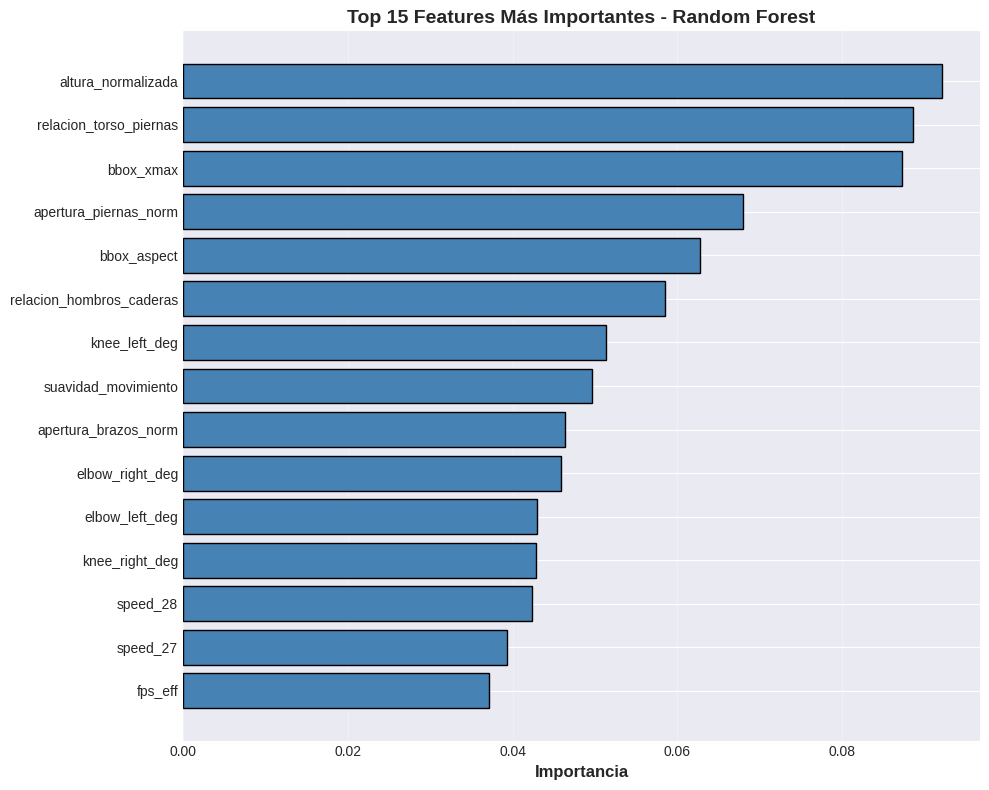

In [13]:
# === 5.4. Importancia de Features (para Random Forest o XGBoost) ===
print(f"\nINFO Análisis de Importancia de Features:")

# Mostrar importancia de Random Forest (siempre disponible)
print("\n[ MODEL ] Random Forest - Top 15 Features:")
print("-" * 60)
rf_importances = rf_model.feature_importances_
rf_importance_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance': rf_importances
}).sort_values('importance', ascending=False)

print(rf_importance_df.head(15).to_string(index=False))

# Mostrar importancia de XGBoost si está disponible
if XGBOOST_AVAILABLE:
    print("\n[ MODEL ] XGBoost - Top 15 Features:")
    print("-" * 60)
    xgb_importances = xgb_model.feature_importances_
    xgb_importance_df = pd.DataFrame({
        'feature': X_train_scaled.columns,
        'importance': xgb_importances
    }).sort_values('importance', ascending=False)
    print(xgb_importance_df.head(15).to_string(index=False))

# Visualización del mejor modelo que tenga importancia de features
if best_model_name == 'Random Forest':
    print(f"\n[ VIEW ] Visualización - Random Forest:")
    importance_df = rf_importance_df
    plt.figure(figsize=(10, 8))
    top_features = importance_df.head(15)
    plt.barh(range(len(top_features)), top_features['importance'], color='steelblue', edgecolor='black')
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importancia', fontsize=12, fontweight='bold')
    plt.title(f'Top 15 Features Más Importantes - Random Forest', 
              fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
elif best_model_name == 'XGBoost' and XGBOOST_AVAILABLE:
    print(f"\n[ VIEW ] Visualización - XGBoost:")
    importance_df = xgb_importance_df
    plt.figure(figsize=(10, 8))
    top_features = importance_df.head(15)
    plt.barh(range(len(top_features)), top_features['importance'], color='steelblue', edgecolor='black')
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importancia', fontsize=12, fontweight='bold')
    plt.title(f'Top 15 Features Más Importantes - XGBoost', 
              fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\n[ WARN ] SVM no proporciona importancia de features directamente")


## 6. Guardar Modelos Entrenados


In [14]:
# Guardar todos los modelos entrenados
print("[ SAVE ] Guardando modelos entrenados...\n")

try:
    joblib.dump(rf_model, 'rf_model.joblib')
    print("[ OK ] Random Forest guardado: rf_model.joblib")
    
    if XGBOOST_AVAILABLE:
        joblib.dump(xgb_model, 'xgb_model.joblib')
        print("[ OK ] XGBoost guardado: xgb_model.joblib")
    
    joblib.dump(svm_model, 'svm_model.joblib')
    print("[ OK ] SVM guardado: svm_model.joblib")
    
    # Guardar también el mejor modelo con nombre especial
    joblib.dump(best_model, 'best_model.joblib')
    print(f"[ OK ] Mejor modelo ({best_model_name}) guardado: best_model.joblib")
    
    print("\n[ OK ] Todos los modelos guardados exitosamente")
except Exception as e:
    print(f"[ WARN ] Error al guardar modelos: {e}")


[ SAVE ] Guardando modelos entrenados...

[ OK ] Random Forest guardado: rf_model.joblib
[ OK ] XGBoost guardado: xgb_model.joblib
[ OK ] SVM guardado: svm_model.joblib
[ OK ] Mejor modelo (Random Forest) guardado: best_model.joblib

[ OK ] Todos los modelos guardados exitosamente


## 7. Resumen y Conclusiones

### Resultados Principales:

Los resultados del mejor modelo se muestran en las celdas anteriores. Revisa:
- Matriz de confusión para ver qué clases son más difíciles
- Reporte de clasificación por clase
- Métricas finales en Test Set

### Recomendaciones para Mejoras Futuras:

1. **Ajuste de Hiperparámetros**: Usar GridSearchCV o RandomizedSearchCV para optimizar parámetros
2. **Balanceo de Clases**: Si algunas clases tienen bajo rendimiento, considerar SMOTE o técnicas de oversampling
3. **Feature Engineering**: Analizar si agregar más features temporales o espaciales ayuda
4. **Validación Cruzada**: Implementar k-fold cross-validation para evaluación más robusta
5. **Ensemble Methods**: Combinar predicciones de múltiples modelos para mejorar rendimiento

---
